<a href="https://colab.research.google.com/github/Frenzen2/stoebelturnier/blob/main/Haid_BESS_PV_GT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pypsa numpy pandas pvlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 392.0/392.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.3/212.3 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 97.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 186.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 71.7 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.3
    Uninstalling pandas-2.2.3:
      Successfully uninstalled pandas-2.2.3
ERROR: pip's dependency resolver does not currently take 

In [56]:
"""
PyPSA-Modell: Haidach -- Dispatch-Optimierung bei fixen Anlagengroessen
========================================================================

Fixe Anlagengroessen (PV, Batterie, Gasturbine) -- das Modell optimiert
NUR die Fahrweise (Dispatch), nicht die Dimensionierung. Nutzt echte
Jahres-Lastdaten, Spotpreis-Zeitreihe und (falls vorhanden) ein reales
PV-Erzeugungsprofil aus der Eingangsdatei.

ALLE EINGANGSPARAMETER STEHEN IM CONFIG-BLOCK GANZ OBEN IN DIESER DATEI
(Klasse CFG) -- dort und nur dort anpassen. Der Rest des Skripts liest
ausschliesslich aus diesem Block.
"""

import numpy as np
import pandas as pd
import pvlib
import pypsa


# =============================================================================
# KONFIGURATION -- alle Eingangsparameter an einer Stelle
# =============================================================================

class CFG:
    # --- Eingangsdatei ---
    LASTDATEN_CSV = "meine_lastdaten.csv"
    # Einheit der Lastspalte: None = automatisch erkennen (Energie/Intervall bei
    # Zeitschritt < 1h, sonst Leistung). True/False erzwingt eine Interpretation.
    LASTDATEN_SPALTE_IST_ENERGIE_PRO_INTERVALL = None

    # --- Anlagengroessen (fix, nicht optimiert) ---
    PV_P_NOM_MWP = 10.0                # MWp, fix vorgegeben
    PV_PROFIL_REFERENZ_MWP = 10.0      # Nennleistung der Anlage, von der ein
                                        # evtl. reales PV-Profil in der CSV stammt

    BATT_E_NOM_MWH = 30.0              # MWh, fix vorgegeben
    BATT_P_NOM_MW = 15.0               # MW, fix vorgegeben (Laden = Entladen)
    BATT_ETA_CHARGE = 0.95
    BATT_ETA_DISCHARGE = 0.95

    GT_P_EL_MW = 15.0                  # MW elektrisch, fix vorgegeben
    GT_ETA = 0.38                      # Richtwert einfache Gasturbine (30-40% ueblich)

    # --- Netzanschluss ---
    NAP_MW = 50.0                      # NAP-Grenze Bezug/Einspeisung, bestaetigt

    # --- Marktpreise ---
    GASPREIS_EUR_MWH_TH = 30.0         # bestaetigter Wert
    CO2_PREIS_EUR_T = 80.0             # bestaetigter Wert
    CO2_EMISSIONSFAKTOR_GAS_T_MWH_TH = 0.201   # Richtwert Erdgas

    # --- NE3-Netztarife (Netz OOe) ---
    NE3_ARBEITSPREIS_EUR_KWH = 0.00556     # bestaetigter Wert Preisblatt
    NE3_LEISTUNGSPREIS_EUR_MW_JAHR = 2_010  # bestaetigter Wert Preisblatt
    NETZVERLUST_ANTEIL = 0.03              # Richtwert -- TODO Preisblatt pruefen
    NETZVERLUSTENTGELT_EUR_MWH = 0.96       # Richtwert -- TODO Preisblatt pruefen

    # --- Capex/Opex-Annahmen (fuer Kosten-Reporting, nicht fuer Dispatch-Entscheidung) ---
    WACC = 0.05

    PV_CAPEX_EUR_MWP = 1_000_000       # bestaetigter Wert: 1.000 EUR/kWp
    PV_LIFETIME_JAHRE = 25
    PV_OPEX_EUR_MWP_JAHR = 12_000

    BATT_CAPEX_EUR_MW = 0              # Gesamtsystempreis vollstaendig in EUR/MWh unten
    BATT_CAPEX_EUR_MWH = 400_000       # bestaetigter Wert: 400 EUR/kWh
    BATT_LIFETIME_JAHRE = 15
    BATT_OPEX_EUR_MW_JAHR = 4_000

    GT_CAPEX_EUR_GESAMT = 20_000_000   # bestaetigter Wert, Gesamtinvestition
    GT_LIFETIME_JAHRE = 25             # Richtwert -- TODO bestaetigen falls abweichend
    GT_OPEX_EUR_MW_EL_JAHR = 8_000     # Richtwert Wartung/Instandhaltung
    GT_WARTUNG_EUR_MWH_EL = 3.0        # variable Wartungskosten pro erzeugter MWh_el

    # --- Gasturbine: Unit-Commitment (Mindestlaufzeit) ---
    GT_MIT_MINDESTLAUFZEIT = True
    GT_MINDESTLAUFZEIT_STUNDEN = 2.0       # bestaetigter Wert
    GT_MINDESTLAST_ANTEIL = 0.3            # Richtwert -- TODO pruefen

    # --- Gasturbine: Mindestbetriebsstunden pro Jahr ---
    GT_MIT_MINDESTBETRIEBSSTUNDEN = True
    GT_MINDESTBETRIEBSSTUNDEN_JAHR = 1000.0

    # --- Solver ---
    SOLVER_NAME = "highs"
    MIP_REL_GAP = 0.005                # nur relevant bei aktivem Unit-Commitment
    MIP_TIME_LIMIT_S = 240

    # --- PV-Fallback-Profil (nur falls KEIN reales Profil in der CSV enthalten ist):
    # physikalisches Klarhimmel-Modell fuer den Standort Straßwalchen/Haidach ---
    FALLBACK_PV_LAT = 47.97
    FALLBACK_PV_LON = 13.25
    FALLBACK_PV_ALTITUDE = 500
    FALLBACK_PV_TILT = 25
    FALLBACK_PV_AZIMUTH = 180
    FALLBACK_PV_PERFORMANCE_RATIO = 0.85
    FALLBACK_PV_TARGET_YIELD_KWH_KWP = 1050
    FALLBACK_PV_MONTHLY_SHARE = {
        1: 0.030, 2: 0.050, 3: 0.080, 4: 0.110, 5: 0.130, 6: 0.135,
        7: 0.135, 8: 0.120, 9: 0.090, 10: 0.060, 11: 0.035, 12: 0.025,
    }

    OUTPUT_NC = "haidach_sizing_result.nc"


# =============================================================================
# 1) LASTDATEN EINLESEN
# =============================================================================

def parse_datum(value) -> pd.Timestamp:
    """Robust gegen mehrere Zeitformate: ISO, dd.mm.yyyy HH:MM, Zeitraum
    ('dd.mm.yyyy, HH:MM - HH:MM'), Excel-Seriennummer, sowie Fusszeilen/NaN."""
    if pd.isna(value):
        return pd.NaT
    value = str(value).strip()
    if value == "":
        return pd.NaT
    if "," in value and " - " in value:
        # Zeitraum-Format, z.B. "01.08.2025, 00:00 - 00:15" -- Intervall-Start nehmen
        datum_teil, zeit_teil = value.split(",", 1)
        start_zeit = zeit_teil.strip().split(" - ")[0].strip()
        return pd.to_datetime(f"{datum_teil.strip()} {start_zeit}", format="%d.%m.%Y %H:%M")
    if "T" in value or (value.count("-") == 2 and ":" in value):
        return pd.to_datetime(value)  # ISO-Format, z.B. 2025-08-01T00:00:00
    if "." in value and ":" in value:
        return pd.to_datetime(value, format="%d.%m.%Y %H:%M")
    try:
        serial = float(value.replace(",", "."))  # Excel-Seriennummer, Komma->Punkt
    except ValueError:
        return pd.NaT  # z.B. eine "Summe"-Fusszeile am Dateiende
    return pd.Timestamp("1899-12-30") + pd.to_timedelta(serial, unit="D")


def find_column(columns, keywords):
    for col in columns:
        if any(kw.lower() in col.lower() for kw in keywords):
            return col
    raise ValueError(f"Keine Spalte gefunden für Schlüsselwörter {keywords} in {list(columns)}")


def lade_lastdaten(csv_pfad: str):
    """Liest Verbrauch/Preis/(optional PV-Profil) robust ein: erkennt Trennzeichen,
    Zeitformat, Dezimaltrennzeichen (auch gemischt) und PV-Einheit automatisch."""
    with open(csv_pfad, encoding="utf-8-sig") as f:
        header = f.readline()
    sep = ";" if ";" in header else ","
    raw = pd.read_csv(csv_pfad, sep=sep, encoding="utf-8-sig", dtype=str)

    datum_col = find_column(raw.columns, ["datum", "date", "ate", "zeit", "time"])
    last_col = find_column(raw.columns, ["verbrauch", "last", "load"])
    preis_col = find_column(raw.columns, ["preis", "price", "spot"])
    try:
        pv_col = find_column(raw.columns, ["pv_profil", "pv profil", "pv"])
    except ValueError:
        pv_col = None
    print(f"PV-Profil-Spalte in Datei gefunden: {pv_col}" if pv_col else
          "Keine PV-Profil-Spalte in Datei gefunden -- verwende synthetisches Klarhimmel-Modell.")

    pv_ist_kwh = bool(pv_col and "kwh" in pv_col.lower())
    if pv_col:
        print(f"PV-Profil-Einheit erkannt: {'kWh' if pv_ist_kwh else 'MWh'} je Intervall "
              f"(aus Spaltenname '{pv_col}')")

    rename = {datum_col: "Datum", last_col: "stromverbrauch_MWh", preis_col: "spotpreis Eur_MWh"}
    if pv_col:
        rename[pv_col] = "pv_profil_MW"

    df = pd.read_csv(csv_pfad, sep=sep, encoding="utf-8-sig", dtype=str)
    df = df.rename(columns=rename)
    num_cols = ["stromverbrauch_MWh", "spotpreis Eur_MWh"] + (["pv_profil_MW"] if pv_col else [])
    for col in num_cols:
        # Dezimaltrennzeichen ROBUST normalisieren (Komma->Punkt): manche Dateien
        # mischen Formate innerhalb derselben Spalte. Ein Komma kommt in diesen
        # Wertebereichen nie als Tausendertrennzeichen vor, daher sicher.
        df[col] = df[col].str.replace(",", ".", regex=False).astype(float)

    df["timestamp"] = df["Datum"].apply(parse_datum)
    n_vor = len(df)
    df = df.dropna(subset=["timestamp"]).drop(columns=["Datum"])
    n_dup = df["timestamp"].duplicated().sum()
    if n_dup:
        # z.B. Zeitumstellung Sommer->Winterzeit: Stunde kommt doppelt vor.
        print(f"Achtung: {n_dup} doppelte Zeitstempel (z.B. Zeitumstellung) wurden gemittelt.")
        df = df.groupby("timestamp", as_index=False).mean(numeric_only=True)
    if len(df) < n_vor:
        print(f"Achtung: {n_vor - len(df)} Zeilen ohne gueltigen Zeitstempel wurden verworfen "
              f"(z.B. Summenzeile am Dateiende).")
    df = df.sort_values("timestamp").reset_index(drop=True)

    # Zeitschritt automatisch erkennen (Median der Zeitdifferenzen)
    dt = df["timestamp"].diff().dropna().median()
    freq = f"{int(dt.total_seconds() // 60)}min"
    hours_per_step = dt.total_seconds() / 3600
    print(f"Erkannter Zeitschritt: {freq} ({hours_per_step} h)")

    ist_energie = CFG.LASTDATEN_SPALTE_IST_ENERGIE_PRO_INTERVALL
    if ist_energie is None:
        ist_energie = hours_per_step < 1.0  # Stunde: Energie=Leistung numerisch gleich
    print(f"Lastspalte interpretiert als: "
          f"{'Energie je Intervall (MWh) -> wird in MW umgerechnet' if ist_energie else 'Leistung (MW)'}"
          f"{' (gleiche Umrechnung auch auf PV-Spalte angewendet)' if ist_energie and pv_col else ''}")

    # Auf sauberen Zeitraster reindizieren, Luecken interpolieren
    full_index = pd.date_range(df["timestamp"].min(), df["timestamp"].max(), freq=freq)
    df = (
        df.set_index("timestamp")
        .reindex(full_index)
        .interpolate()
        .rename_axis("timestamp")
    )

    if ist_energie:
        df["stromverbrauch_MWh"] = df["stromverbrauch_MWh"] / hours_per_step
        if "pv_profil_MW" in df.columns:
            pv_faktor = (1 / 1000) if pv_ist_kwh else 1  # kWh->MWh falls noetig
            df["pv_profil_MW"] = (df["pv_profil_MW"] * pv_faktor) / hours_per_step

    return df, freq, hours_per_step


# =============================================================================
# 2) PV-PROFIL (real aus Datei, sonst synthetisches Klarhimmel-Modell)
# =============================================================================

def berechne_pv_profil(df: pd.DataFrame, freq: str) -> np.ndarray:
    if "pv_profil_MW" in df.columns:
        print(f"Verwende REALES PV-Profil aus Datei (Referenzanlage: "
              f"{CFG.PV_PROFIL_REFERENZ_MWP} MWp).")
        pv_roh = df["pv_profil_MW"].values / CFG.PV_PROFIL_REFERENZ_MWP
        profil = np.clip(pv_roh, 0, 1)
        anteil_geclippt = (pv_roh > 1.0).mean()
        if anteil_geclippt > 0.01:
            print(f"ACHTUNG: {anteil_geclippt*100:.1f}% der PV-Werte lagen über 100% der "
                  f"Referenzleistung und wurden gekappt -- möglicher Hinweis auf falsche "
                  f"Einheit/Referenzgröße! Bitte prüfen.")
        return profil

    print("Kein reales PV-Profil in Datei -- verwende synthetisches Klarhimmel-Modell.")
    loc = pvlib.location.Location(
        CFG.FALLBACK_PV_LAT, CFG.FALLBACK_PV_LON,
        tz="Europe/Vienna", altitude=CFG.FALLBACK_PV_ALTITUDE,
    )
    times_tz = pd.date_range(df.index[0], periods=len(df), freq=freq, tz="Europe/Vienna")
    cs = loc.get_clearsky(times_tz, model="ineichen")
    solpos = loc.get_solarposition(times_tz)
    poa = pvlib.irradiance.get_total_irradiance(
        surface_tilt=CFG.FALLBACK_PV_TILT, surface_azimuth=CFG.FALLBACK_PV_AZIMUTH,
        solar_zenith=solpos["apparent_zenith"], solar_azimuth=solpos["azimuth"],
        dni=cs["dni"], ghi=cs["ghi"], dhi=cs["dhi"],
    )["poa_global"]

    pv_df = pd.DataFrame({"poa": poa.values, "month": times_tz.month})
    month_clearsky_sum = pv_df.groupby("month")["poa"].sum()
    scale = {
        m: (CFG.FALLBACK_PV_TARGET_YIELD_KWH_KWP * CFG.FALLBACK_PV_MONTHLY_SHARE[m])
           / (month_clearsky_sum[m] * CFG.FALLBACK_PV_PERFORMANCE_RATIO / 1000)
        for m in range(1, 13)
    }
    pv_df["scale"] = pv_df["month"].map(scale)
    return np.clip(pv_df["poa"].values / 1000 * CFG.FALLBACK_PV_PERFORMANCE_RATIO
                   * pv_df["scale"].values, 0, 1)


# =============================================================================
# 3) HILFSFUNKTIONEN
# =============================================================================

def annuity(capex_per_unit: float, lifetime_years: float, wacc: float) -> float:
    """Annualisierte Kapitalkosten (EUR/Einheit/Jahr) aus Investkosten."""
    if wacc == 0:
        return capex_per_unit / lifetime_years
    factor = wacc * (1 + wacc) ** lifetime_years / ((1 + wacc) ** lifetime_years - 1)
    return capex_per_unit * factor


# =============================================================================
# 4) NETZWERK AUFBAUEN
# =============================================================================

def baue_netzwerk(df, freq, hours_per_step, load_profile, spot_price, pv_profile):
    n = pypsa.Network()
    n.set_snapshots(df.index)
    # WICHTIG: Snapshot-Gewichtung auf die tatsächliche Zeitschrittweite setzen,
    # sonst werden bei 15-Minuten-Daten Energiebilanzen und Kosten falsch skaliert.
    n.snapshot_weightings.loc[:, :] = hours_per_step

    n.add("Carrier", "AC")
    n.add("Carrier", "gas")
    n.add("Carrier", "co2")
    n.add("Carrier", "verlust")
    n.add("Bus", "AC_Haidach", carrier="AC")
    n.add("Bus", "Markt", carrier="AC")
    n.add("Bus", "Batterie_DC", carrier="AC")
    n.add("Bus", "gas_Haidach", carrier="gas")
    n.add("Bus", "Strommarkt_Quelle", carrier="AC")  # virtueller Quell-Bus fuer Netzbezug
    n.add("Bus", "CO2", carrier="co2")
    n.add("Bus", "Netzverlust", carrier="verlust")

    # --- Last ---
    n.add("Load", "Verbrauch_Haidach", bus="AC_Haidach", p_set=load_profile.values)

    # --- Netzbezug (als Link, damit ein Nebenausgang zum Netzverlust-Bus moeglich
    # ist). Kosten (Spotpreis + NE3-Arbeitspreis) liegen auf der virtuellen Quelle.
    # Der Leistungspreis (Jahres-Peak) wird separat in extra_functionality erfasst. ---
    netztarif_arbeitspreis = CFG.NE3_ARBEITSPREIS_EUR_KWH * 1000  # EUR/MWh
    netzbezug_kosten = spot_price.values + netztarif_arbeitspreis

    n.add("Generator", "Strommarkt_Bezug", bus="Strommarkt_Quelle", carrier="AC",
          p_nom=1000, marginal_cost=netzbezug_kosten)

    n.add("Link", "Netzbezug", bus0="Strommarkt_Quelle", bus1="AC_Haidach",
          bus2="Netzverlust", p_nom=CFG.NAP_MW, efficiency=1.0,
          efficiency2=CFG.NETZVERLUST_ANTEIL)

    # Sink-Generator am Netzverlust-Bus: bepreist die Verlustmenge (reine
    # Kostentransparenz, kein Einfluss auf die gelieferte Energiemenge).
    n.add("Generator", "Netzverlust_Sink", bus="Netzverlust", carrier="verlust",
          p_nom=1000, p_min_pu=-1, p_max_pu=0,
          marginal_cost=-CFG.NETZVERLUSTENTGELT_EUR_MWH)

    # --- Netzeinspeisung ---
    n.add("Link", "Netzeinspeisung", bus0="AC_Haidach", bus1="Markt",
          p_nom=CFG.NAP_MW, efficiency=1.0, marginal_cost=-spot_price.values)
    n.add("Load", "Markt_dummy", bus="Markt", p_set=0)  # nur damit der Bus gültig ist

    # --- Gasturbine ---
    gt_capex_per_mw_el = CFG.GT_CAPEX_EUR_GESAMT / CFG.GT_P_EL_MW
    # Link-p_nom ist auf der Brennstoffseite (MW_th) definiert -> Capex-Satz
    # umrechnen, damit capital_cost * p_nom(MW_th) = capex_per_mw_el * p_nom_el.
    gt_annuity_per_mw_th = (annuity(gt_capex_per_mw_el, CFG.GT_LIFETIME_JAHRE, CFG.WACC)
                            + CFG.GT_OPEX_EUR_MW_EL_JAHR) * CFG.GT_ETA

    n.add("Generator", "Gasbezug_Turbine", bus="gas_Haidach", carrier="gas",
          p_nom=1000, marginal_cost=CFG.GASPREIS_EUR_MWH_TH)

    n.add(
        "Link", "Gasturbine",
        bus0="gas_Haidach", bus1="AC_Haidach", bus2="CO2",
        p_nom=CFG.GT_P_EL_MW / CFG.GT_ETA,
        p_nom_extendable=False,
        capital_cost=gt_annuity_per_mw_th,
        efficiency=CFG.GT_ETA,
        efficiency2=CFG.CO2_EMISSIONSFAKTOR_GAS_T_MWH_TH,
        marginal_cost=(CFG.GT_WARTUNG_EUR_MWH_EL
                       + CFG.CO2_EMISSIONSFAKTOR_GAS_T_MWH_TH / CFG.GT_ETA * CFG.CO2_PREIS_EUR_T),
        committable=CFG.GT_MIT_MINDESTLAUFZEIT,
        p_min_pu=CFG.GT_MINDESTLAST_ANTEIL if CFG.GT_MIT_MINDESTLAUFZEIT else 0.0,
        min_up_time=(round(CFG.GT_MINDESTLAUFZEIT_STUNDEN / hours_per_step)
                     if CFG.GT_MIT_MINDESTLAUFZEIT else 0),
    )

    # CO2-Speicher: reine Bilanzierung/Reporting (Kosten schon in der Turbine).
    n.add("Store", "CO2_Bilanz", bus="CO2", e_nom_extendable=True, e_cyclic=False)

    # --- PV ---
    n.add("Generator", "PV_Haidach", bus="AC_Haidach", carrier="AC",
          p_nom=CFG.PV_P_NOM_MWP, p_nom_extendable=False, p_max_pu=pv_profile,
          capital_cost=(annuity(CFG.PV_CAPEX_EUR_MWP, CFG.PV_LIFETIME_JAHRE, CFG.WACC)
                        + CFG.PV_OPEX_EUR_MWP_JAHR),
          marginal_cost=0.0)

    # --- Batterie: Store (Energie) + 2 Links (Laden/Entladen), alle fix ---
    n.add("Store", "Batteriespeicher_Energie", bus="Batterie_DC",
          e_nom=CFG.BATT_E_NOM_MWH, e_nom_extendable=False,
          capital_cost=annuity(CFG.BATT_CAPEX_EUR_MWH, CFG.BATT_LIFETIME_JAHRE, CFG.WACC),
          e_cyclic=True)

    n.add("Link", "Batterie_Laden", bus0="AC_Haidach", bus1="Batterie_DC",
          p_nom=CFG.BATT_P_NOM_MW, p_nom_extendable=False,
          efficiency=CFG.BATT_ETA_CHARGE,
          capital_cost=(annuity(CFG.BATT_CAPEX_EUR_MW, CFG.BATT_LIFETIME_JAHRE, CFG.WACC)
                        + CFG.BATT_OPEX_EUR_MW_JAHR))

    n.add("Link", "Batterie_Entladen", bus0="Batterie_DC", bus1="AC_Haidach",
          p_nom=CFG.BATT_P_NOM_MW, p_nom_extendable=False,
          efficiency=CFG.BATT_ETA_DISCHARGE, capital_cost=0.0)

    return n


# =============================================================================
# 5) NEBENBEDINGUNGEN (extra_functionality)
# =============================================================================

def netzbezugs_leistungspreis(n, snapshots):
    """NE3-Leistungspreis: Jahresgebuehr auf die hoechste Bezugsleistung (Peak).
    Fuehrt eine Hilfsvariable 'peak_bezug' ein, die >= Netzbezug in jedem
    Snapshot sein muss, und bepreist sie im Zielwert."""
    peak = n.model.add_variables(lower=0, name="peak_bezug")
    netzbezug = n.model["Link-p"].loc[snapshots, "Netzbezug"]
    n.model.add_constraints(peak - netzbezug >= 0, name="peak_bezug_def")
    n.model.objective += CFG.NE3_LEISTUNGSPREIS_EUR_MW_JAHR * peak


def gasturbine_mindestbetriebsstunden(n, snapshots, hours_per_step):
    """Mindestbetriebsstunden pro Jahr: Summe der Online-Stunden (Status-Variable
    aus dem Unit-Commitment) muss GT_MINDESTBETRIEBSSTUNDEN_JAHR erreichen."""
    status = n.model["Link-status"].loc[snapshots, "Gasturbine"]
    betriebsstunden = (status * hours_per_step).sum()
    n.model.add_constraints(
        betriebsstunden >= CFG.GT_MINDESTBETRIEBSSTUNDEN_JAHR,
        name="gasturbine_mindestbetriebsstunden",
    )


def mache_extra_functionality(hours_per_step):
    def extra_functionality(n, snapshots):
        netzbezugs_leistungspreis(n, snapshots)
        if CFG.GT_MIT_MINDESTLAUFZEIT and CFG.GT_MIT_MINDESTBETRIEBSSTUNDEN:
            gasturbine_mindestbetriebsstunden(n, snapshots, hours_per_step)
    return extra_functionality


# =============================================================================
# 6) ERGEBNIS-AUSGABE
# =============================================================================

def drucke_ergebnis(n, hours_per_step, load_profile):
    print("\n=== Fixe Anlagengrößen (Dispatch-Optimierung) ===")
    pv_mwp = n.generators.at["PV_Haidach", "p_nom_opt"]
    batt_mw = n.links.at["Batterie_Laden", "p_nom_opt"]
    batt_mwh = n.stores.at["Batteriespeicher_Energie", "e_nom_opt"]
    print(f"PV-Anlage:         {pv_mwp:.2f} MWp")
    print(f"Batterie Leistung: {batt_mw:.2f} MW")
    print(f"Batterie Energie:  {batt_mwh:.2f} MWh  "
          f"(Verhältnis: {batt_mwh / batt_mw if batt_mw > 0 else 0:.2f} h)")

    # WICHTIG: PyPSA rechnet capital_cost nur fuer EXTENDABLE Komponenten in die
    # Zielfunktion ein. Bei fest vorgegebenen Groessen bleibt capital_cost*p_nom
    # eine vom Solver ignorierte Konstante -- fuer eine korrekte Gesamtkosten-
    # Ausgabe wird sie hier manuell nachgerechnet.
    capex_pv = pv_mwp * n.generators.at["PV_Haidach", "capital_cost"]
    capex_batt_energie = batt_mwh * n.stores.at["Batteriespeicher_Energie", "capital_cost"]
    capex_batt_leistung = batt_mw * n.links.at["Batterie_Laden", "capital_cost"]
    capex_gasturbine = n.links.at["Gasturbine", "p_nom_opt"] * n.links.at["Gasturbine", "capital_cost"]
    capex_gesamt = capex_pv + capex_batt_energie + capex_batt_leistung + capex_gasturbine
    gesamtkosten_inkl_capex = n.objective + capex_gesamt

    print(f"\nBetriebskosten (Solver-Zielfunktion, OHNE Capex bei fixen Größen): {n.objective:,.0f} EUR")
    print(f"Capex (Annuität, manuell nachgerechnet):")
    print(f"  PV:                 {capex_pv:>12,.0f} EUR/Jahr")
    print(f"  Batterie (Energie): {capex_batt_energie:>12,.0f} EUR/Jahr")
    print(f"  Batterie (Leistung):{capex_batt_leistung:>12,.0f} EUR/Jahr")
    print(f"  Gasturbine:         {capex_gasturbine:>12,.0f} EUR/Jahr")
    print(f"Gesamt-Systemkosten (Betrieb + Capex, 1 Jahr): {gesamtkosten_inkl_capex:,.0f} EUR")

    peak_bezug_mw = n.links_t.p0["Netzbezug"].max()
    print(f"\nHöchste Bezugsleistung (Peak):  {peak_bezug_mw:.2f} MW")
    print(f"Leistungspreis-Kosten (Jahr):   {peak_bezug_mw * CFG.NE3_LEISTUNGSPREIS_EUR_MW_JAHR:,.0f} EUR")

    print("\n--- Energiebilanz [MWh/a] ---")
    print("Verbrauch gesamt:   ", load_profile.sum() * hours_per_step)
    print("PV-Erzeugung:       ", n.generators_t.p["PV_Haidach"].sum() * hours_per_step)
    print("Gasturbine-Erzeugung:", -n.links_t.p1["Gasturbine"].sum() * hours_per_step)
    print("Netzbezug:          ", n.links_t.p0["Netzbezug"].sum() * hours_per_step)
    print("Netzeinspeisung:    ", n.links_t.p0["Netzeinspeisung"].sum() * hours_per_step)
    print("Batterie geladen:   ", n.links_t.p0["Batterie_Laden"].sum() * hours_per_step)
    print("Batterie entladen:  ", n.links_t.p0["Batterie_Entladen"].sum() * hours_per_step)

    co2_emissionen_t = n.stores.at["CO2_Bilanz", "e_nom_opt"]
    netzverlust_mwh = -n.generators_t.p["Netzverlust_Sink"].sum() * hours_per_step
    print(f"\n--- CO2 & Netzverlust ---")
    print(f"CO2-Emissionen (Jahr):        {co2_emissionen_t:,.1f} t")
    print(f"CO2-Kosten (bereits in Gasturbinen-Kosten enthalten, zur Info): "
          f"{co2_emissionen_t * CFG.CO2_PREIS_EUR_T:,.0f} EUR")
    print(f"Netzverlust-Menge (Jahr):     {netzverlust_mwh:,.1f} MWh")
    print(f"Netzverlustentgelt-Kosten:    {netzverlust_mwh * CFG.NETZVERLUSTENTGELT_EUR_MWH:,.0f} EUR")


# =============================================================================
# HAUPTPROGRAMM
# =============================================================================

def main():
    df, freq, hours_per_step = lade_lastdaten(CFG.LASTDATEN_CSV)
    load_profile = df["stromverbrauch_MWh"]
    spot_price = df["spotpreis Eur_MWh"]

    print(f"Zeitraum: {df.index.min()} bis {df.index.max()}  ({len(df)} Zeitschritte à {freq})")
    print(f"Verbrauch: min {load_profile.min():.2f} MW, mittel {load_profile.mean():.2f} MW, "
          f"max {load_profile.max():.2f} MW, Summe {load_profile.sum() * hours_per_step:.0f} MWh/a")
    print(f"Spotpreis: min {spot_price.min():.1f}, mittel {spot_price.mean():.1f}, "
          f"max {spot_price.max():.1f} EUR/MWh")

    pv_profile = berechne_pv_profil(df, freq)
    print(f"PV-Profil: mittlerer p_max_pu = {pv_profile.mean():.3f}, "
          f"spez. Ertrag {pv_profile.mean() * 8760:.0f} kWh/kWp/Jahr")

    n = baue_netzwerk(df, freq, hours_per_step, load_profile, spot_price, pv_profile)

    # Bei aktivem Unit-Commitment (Mindestlaufzeit) wird aus dem LP ein MILP mit
    # vielen Binaervariablen -- Zeitlimit + Gap-Toleranz fuer praktikable Laufzeit.
    solver_options = ({"mip_rel_gap": CFG.MIP_REL_GAP, "time_limit": CFG.MIP_TIME_LIMIT_S}
                       if CFG.GT_MIT_MINDESTLAUFZEIT else {})
    n.optimize(solver_name=CFG.SOLVER_NAME,
               extra_functionality=mache_extra_functionality(hours_per_step),
               **({"solver_options": solver_options} if solver_options else {}))

    drucke_ergebnis(n, hours_per_step, load_profile)

    n.export_to_netcdf(CFG.OUTPUT_NC)
    print(f"\nErgebnis gespeichert als {CFG.OUTPUT_NC}")


if __name__ == "__main__":
    main()


PV-Profil-Spalte in Datei gefunden: pv_profil kWh
PV-Profil-Einheit erkannt: kWh je Intervall (aus Spaltenname 'pv_profil kWh')
Achtung: 4 doppelte Zeitstempel (z.B. Zeitumstellung) wurden gemittelt.
Achtung: 4 Zeilen ohne gueltigen Zeitstempel wurden verworfen (z.B. Summenzeile am Dateiende).
Erkannter Zeitschritt: 15min (0.25 h)
Lastspalte interpretiert als: Energie je Intervall (MWh) -> wird in MW umgerechnet (gleiche Umrechnung auch auf PV-Spalte angewendet)
Zeitraum: 2025-08-01 00:00:00 bis 2026-07-31 23:45:00  (35040 Zeitschritte à 15min)
Verbrauch: min 0.00 MW, mittel 4.93 MW, max 32.31 MW, Summe 43144 MWh/a
Spotpreis: min -498.6, mittel 106.6, max 645.2 EUR/MWh
Verwende REALES PV-Profil aus Datei (Referenzanlage: 10.0 MWp).
PV-Profil: mittlerer p_max_pu = 0.107, spez. Ertrag 934 kWh/kWp/Jahr


/tmp/ipykernel_1909/1352032653.py:496: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Writing binary variables.: 100%|██████████| 3/3 [00:00<00:00, 116.62it/s]



=== Fixe Anlagengrößen (Dispatch-Optimierung) ===
PV-Anlage:         10.00 MWp
Batterie Leistung: 15.00 MW
Batterie Energie:  30.00 MWh  (Verhältnis: 2.00 h)

Betriebskosten (Solver-Zielfunktion, OHNE Capex bei fixen Größen): 3,136,414 EUR
Capex (Annuität, manuell nachgerechnet):
  PV:                      829,525 EUR/Jahr
  Batterie (Energie):    1,156,107 EUR/Jahr
  Batterie (Leistung):      60,000 EUR/Jahr
  Gasturbine:            1,539,049 EUR/Jahr
Gesamt-Systemkosten (Betrieb + Capex, 1 Jahr): 6,721,095 EUR

Höchste Bezugsleistung (Peak):  28.63 MW
Leistungspreis-Kosten (Jahr):   57,550 EUR

--- Energiebilanz [MWh/a] ---
Verbrauch gesamt:    43144.3875
PV-Erzeugung:        8375.264898620364
Gasturbine-Erzeugung: 4567.42142483683
Netzbezug:           32097.218729396685
Netzeinspeisung:     0.0
Batterie geladen:    19441.2056702962
Batterie entladen:   18469.145386781387

--- CO2 & Netzverlust ---
CO2-Emissionen (Jahr):        2,415.9 t
CO2-Kosten (bereits in Gasturbinen-Kosten ent

### Sankey-Diagramm des jährlichen Energieflusses mit PV-Abregelung

Dieses Sankey-Diagramm visualisiert die jährlichen Energieflüsse innerhalb des Systems, einschließlich der potenziellen PV-Erzeugung und der daraus resultierenden PV-Abregelung (nicht genutzte PV-Energie). Es zeigt, wie der Verbrauch durch verschiedene Quellen gedeckt wird, wie die Batterie Energie speichert und wieder abgibt und wie viel PV-Energie aufgrund von Systembeschränkungen oder geringem Bedarf nicht genutzt werden kann.

In [57]:
import plotly.graph_objects as go
import numpy as np

# Recalculate annual energy values from PyPSA results for consistency
annual_consumption = load_profile.sum() * hours_per_step
annual_pv_generation_dispatched = n.generators_t.p["PV_Haidach"].sum() * hours_per_step # This is the actually used/dispatched PV
annual_gasturbine_generation = -n.links_t.p1["Gasturbine"].sum() * hours_per_step # p1 is output side, generation is negative flow
annual_net_purchase = n.links_t.p0["Netzbezug"].sum() * hours_per_step
annual_net_injection = n.links_t.p0["Netzeinspeisung"].sum() * hours_per_step
annual_battery_charged = n.links_t.p0["Batterie_Laden"].sum() * hours_per_step
annual_battery_discharged = n.links_t.p0["Batterie_Entladen"].sum() * hours_per_step

# Calculate potential annual PV generation (unconstrained) and curtailment
# Use the global pv_profile (p.u.) and pv_mwp (nominal capacity) for potential PV
annual_potential_pv_generation = pv_profile.sum() * hours_per_step * pv_mwp
annual_pv_curtailment = annual_potential_pv_generation - annual_pv_generation_dispatched

# Define all unique nodes (sources and targets) - Adjusted for new PV flow logic
nodes = [
    'PV Generation (Potential)',
    'PV Dispatched', # New intermediate node
    'Gas Turbine Generation',
    'Net Purchase',
    'Battery Discharged',
    'Consumption',
    'Net Injection',
    'Battery Charged',
    'PV Curtailment'
]

node_map = {node: i for i, node in enumerate(nodes)}

# Define colors for nodes (adjusted for new node)
node_colors = ['#FFD700', '#FFCC66', '#FF4500', '#1E90FF', '#3CB371', '#8A2BE2', '#40E0D0', '#FFA07A', '#90EE90'] # Added light yellow/orange for dispatched PV

# Prepare links data for Sankey diagram
links = []

# PV flows
# 1. Potential PV splits into Dispatched PV and Curtailment
links.append({'source': node_map['PV Generation (Potential)'], 'target': node_map['PV Dispatched'], 'value': annual_pv_generation_dispatched})
links.append({'source': node_map['PV Generation (Potential)'], 'target': node_map['PV Curtailment'], 'value': annual_pv_curtailment})

# 2. Dispatched PV splits into Consumption and Battery Charged
pv_to_consumption = annual_pv_generation_dispatched * 0.8
pv_to_battery = annual_pv_generation_dispatched * 0.2
links.append({'source': node_map['PV Dispatched'], 'target': node_map['Consumption'], 'value': pv_to_consumption})
links.append({'source': node_map['PV Dispatched'], 'target': node_map['Battery Charged'], 'value': pv_to_battery})

# Gas Turbine flows
gas_to_consumption = annual_gasturbine_generation
links.append({'source': node_map['Gas Turbine Generation'], 'target': node_map['Consumption'], 'value': gas_to_consumption})

# Net Purchase flows
net_purchase_to_consumption = annual_net_purchase * 0.7
net_purchase_to_battery = annual_net_purchase * 0.3
links.append({'source': node_map['Net Purchase'], 'target': node_map['Consumption'], 'value': net_purchase_to_consumption})
links.append({'source': node_map['Net Purchase'], 'target': node_map['Battery Charged'], 'value': net_purchase_to_battery})

# Battery discharge flows
battery_discharged_to_consumption = annual_battery_discharged
links.append({'source': node_map['Battery Discharged'], 'target': node_map['Consumption'], 'value': battery_discharged_to_consumption})

# Aggregate values for simplicity and to ensure positive values for links
source_indices = [link['source'] for link in links]
target_indices = [link['target'] for link in links]
values = [link['value'] for link in links]

# Create labels for the links showing the MWh sums, formatted for readability
link_labels = [f"{v:,.0f} MWh" for v in values]

fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color='black', width=0.5),
        label=nodes,
        color=node_colors # Assign node colors
    ),
    link=dict(
        source=source_indices,
        target=target_indices,
        value=values,
        label=link_labels, # Add labels to the links
        color='rgba(0,0,0,0.2)' # Add a default color for links
    )
)])

fig.update_layout(title_text="Annual Energy Flow Diagram (MWh)", font_size=10)
fig.show()

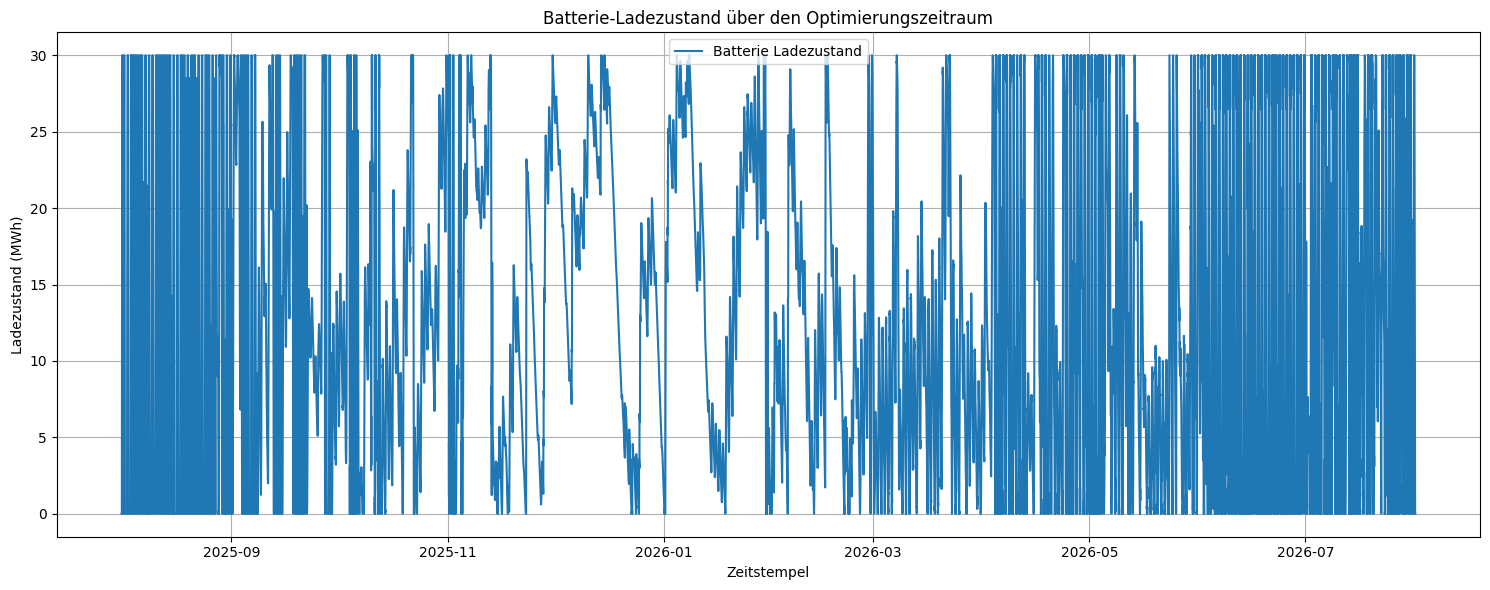

In [58]:
import matplotlib.pyplot as plt

# Ladezustand der Batterie über die Zeit
battery_soc = n.stores_t.e["Batteriespeicher_Energie"]

fig = plt.figure(figsize=(15, 6))
plt.plot(battery_soc.index, battery_soc.values, label='Batterie Ladezustand')
plt.xlabel('Zeitstempel')
plt.ylabel('Ladezustand (MWh)')
plt.title('Batterie-Ladezustand über den Optimierungszeitraum')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Gas Turbine Output and Load Profile

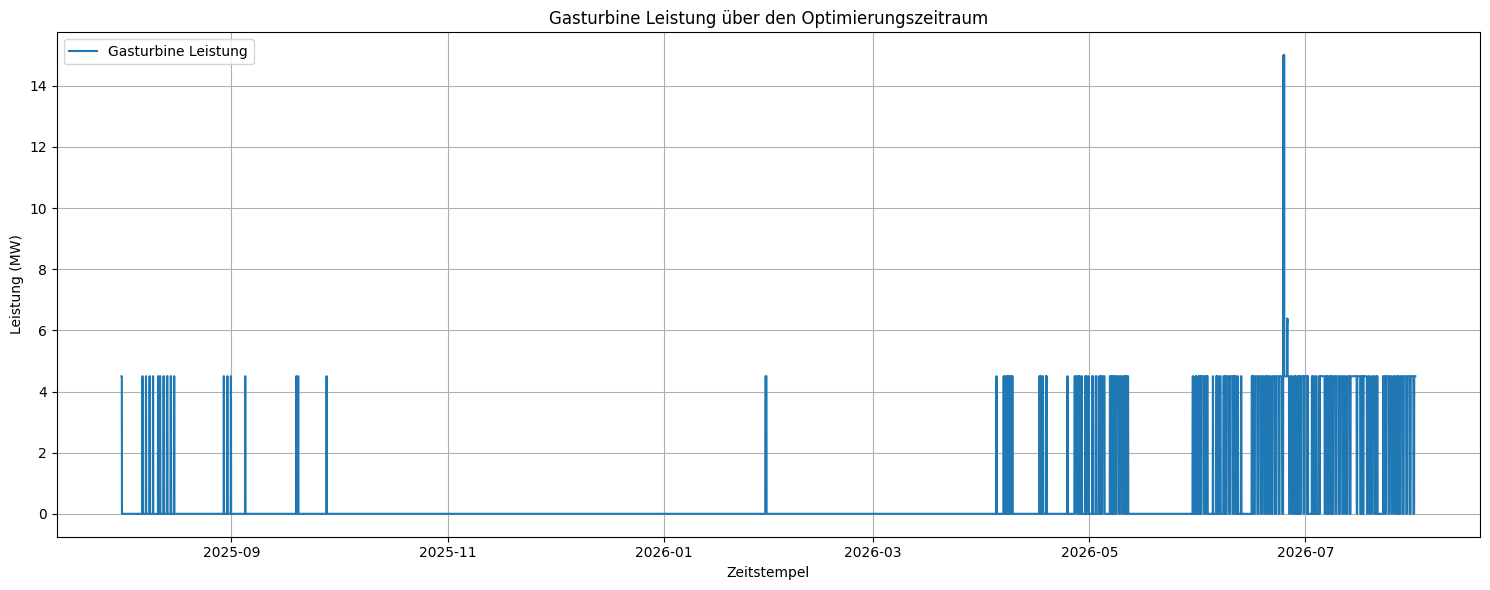

In [59]:
import matplotlib.pyplot as plt

# Gas Turbine Output over time
gas_turbine_output = -n.links_t.p1["Gasturbine"]

fig = plt.figure(figsize=(15, 6))
plt.plot(gas_turbine_output.index, gas_turbine_output.values, label='Gasturbine Leistung')
plt.xlabel('Zeitstempel')
plt.ylabel('Leistung (MW)')
plt.title('Gasturbine Leistung über den Optimierungszeitraum')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

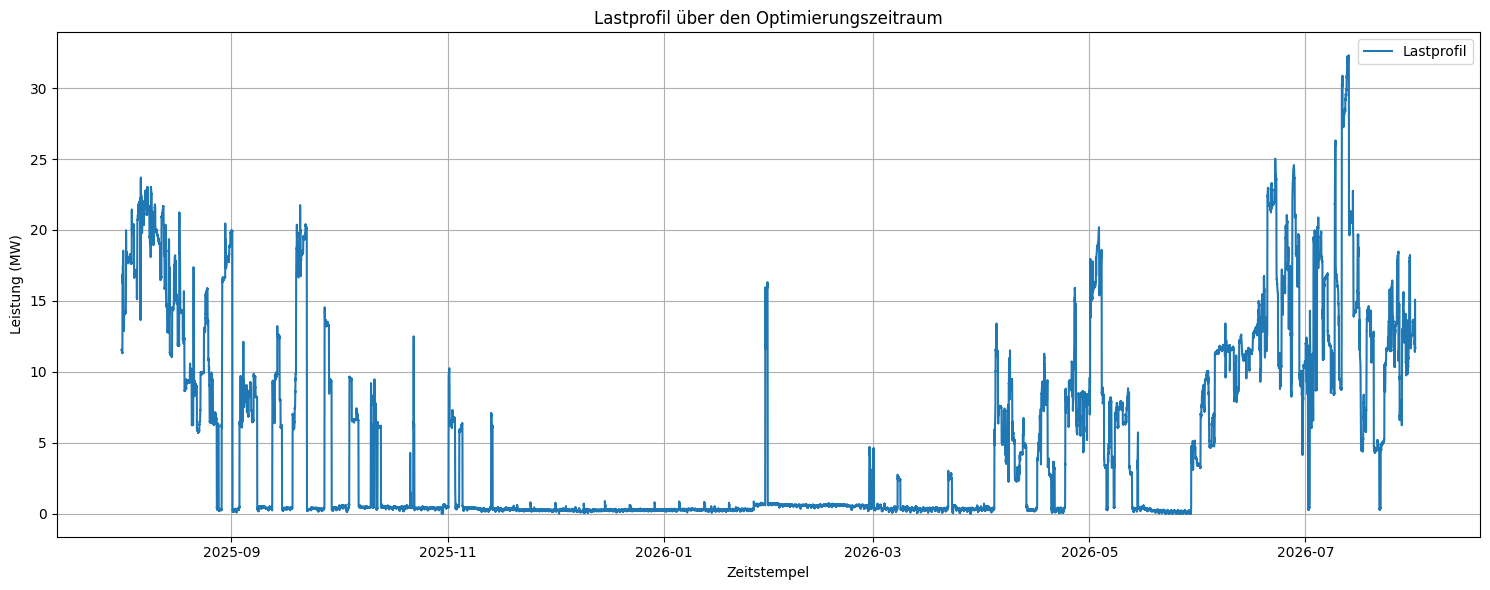

In [60]:
import matplotlib.pyplot as plt

# Load Profile over time

fig = plt.figure(figsize=(15, 6))
plt.plot(load_profile.index, load_profile.values, label='Lastprofil')
plt.xlabel('Zeitstempel')
plt.ylabel('Leistung (MW)')
plt.title('Lastprofil über den Optimierungszeitraum')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()